In [2]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load CSV
df = pd.read_csv("binary_csv_dishwasher data_ Energy Rating Data for household appliances – Labelled Products.csv")

# Create a binary class by changing New Star rating to a greater than catergory

df['StarRatingClass'] = (df['New Star'] > 3).astype(int)  # 1 if Star > 3, else 0

# Drop original New Star column and set class
X = df.drop(columns=['New Star'])
y = df['StarRatingClass']           # Binary target

# One-hot encode categorical features
X = pd.get_dummies(X)

# Save the cleaned binary dataset (optional)
df.to_csv("updated_binary_data.csv", index=False)

Saving binary_csv_dishwasher data_ Energy Rating Data for household appliances – Labelled Products.csv to binary_csv_dishwasher data_ Energy Rating Data for household appliances – Labelled Products.csv


Total samples in dataset: 1338
Multiclass Classification (StarRating):
Kernel: rbf, Accuracy: 0.928


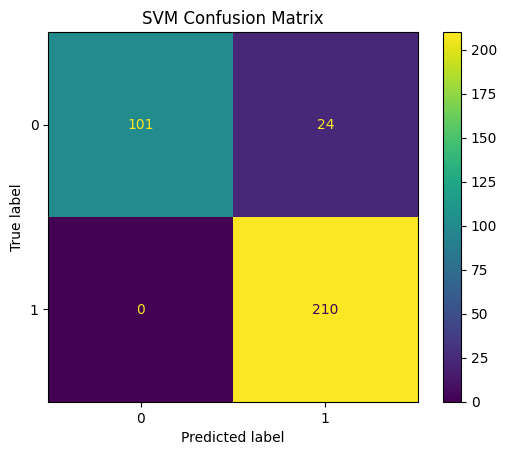

In [23]:
# SVM
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

print("Total samples in dataset:", len(X))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=2)

#  Standardize features
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

#  Train and evaluate SVMs with different kernels
from sklearn.svm import SVC

print("Multiclass Classification (StarRating):")

svm = SVC(kernel='rbf', C=1.0, gamma=1.0, random_state=1)
svm.fit(X_train_std, y_train)
y_pred = svm.predict(X_test_std)
acc = accuracy_score(y_test, y_pred)
print(f"Kernel: rbf, Accuracy: {acc:.3f}")

cm_svm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm_svm).plot()
plt.title("SVM Confusion Matrix")
plt.show()

Number of neighbors: 2, Accuracy: 0.955


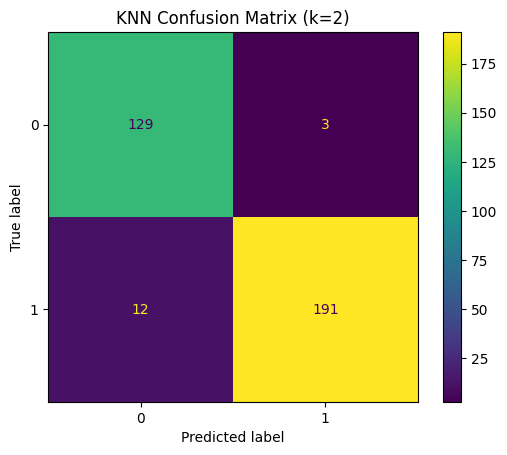

Number of neighbors: 3, Accuracy: 0.943


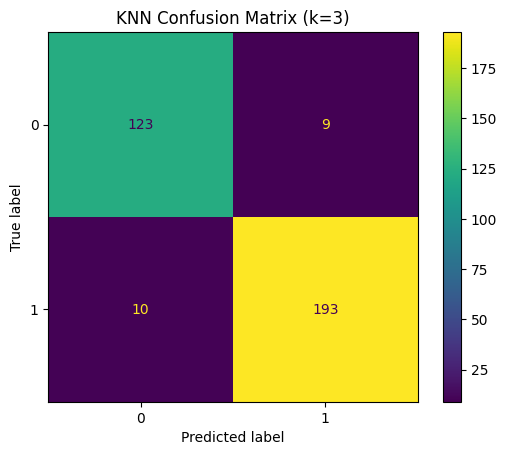

Number of neighbors: 4, Accuracy: 0.931


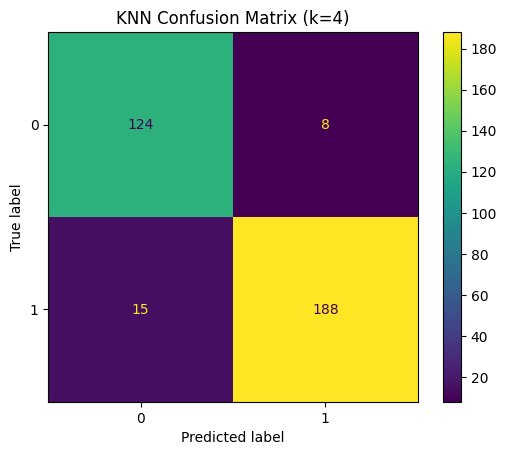

Number of neighbors: 6, Accuracy: 0.901


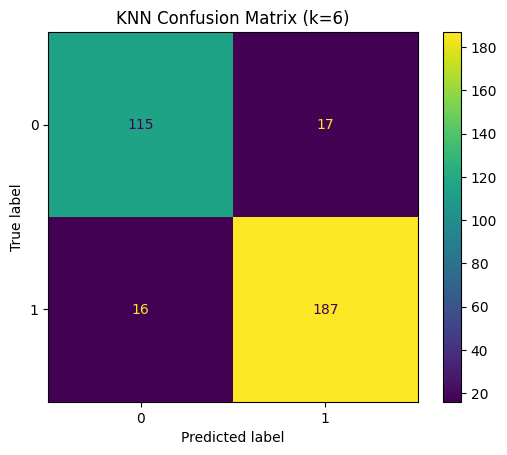

Number of neighbors: 8, Accuracy: 0.887


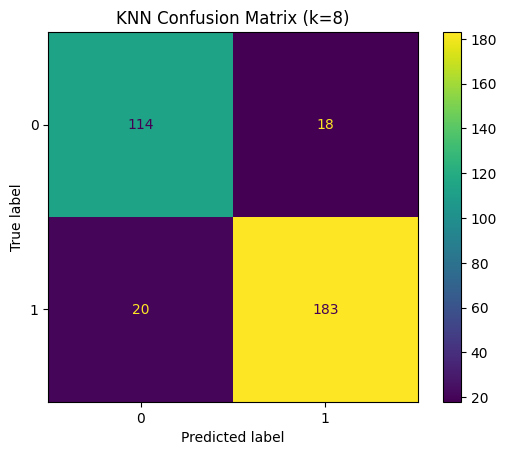

Number of neighbors: 10, Accuracy: 0.901


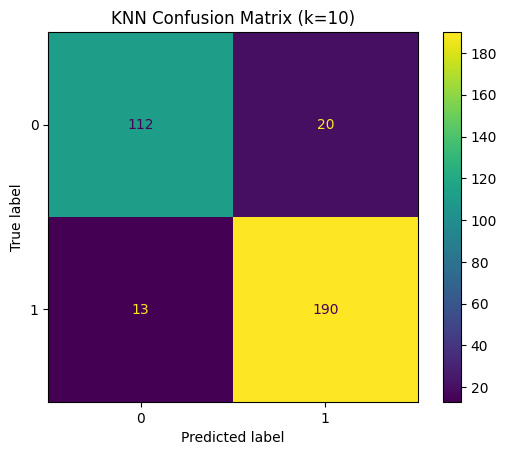

In [11]:
# K-NN Algorithm

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)

#  Standardize features
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

from sklearn.neighbors import KNeighborsClassifier

# use a loop to find the accuaracy for KNN algorithm using a variety of k values
for n_neighbors in [2, 3, 4, 6, 8, 10]:
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(X_train_std, y_train)
    y_pred = knn.predict(X_test_std)
    acc = accuracy_score(y_test, y_pred)
    print(f"Number of neighbors: {n_neighbors}, Accuracy: {acc:.3f}")

  # Show confusion matrix for each k
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"KNN Confusion Matrix (k={n_neighbors})")
    plt.show()

Accuracy: 1.000


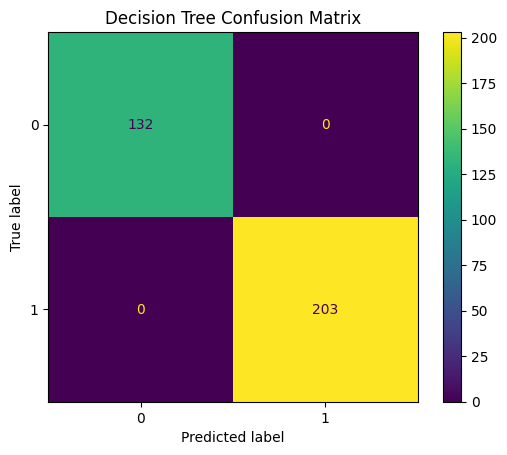

In [19]:
# Decision Tree

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)

tree_model = DecisionTreeClassifier(criterion='gini',
                                    max_depth=2,
                                    random_state=1)
tree_model.fit(X_train, y_train)
y_pred = tree_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.3f}")

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()